# CFTC Disaggregated Report — Energy Futures Ticker Guide

How to filter the disaggregated combined report for the main
energy futures contracts: WTI, Brent, Heating Oil, RBOB, and Gasoil.

The CFTC data contains hundreds of contracts per commodity
(financials, spreads, options, mini contracts, etc.).
This notebook identifies the **primary physical** contract for each.

In [1]:
import pandas as pd

RAW_PATH = '/Users/oualid/Documents/Projects/omroot_repos/cftc_data/cftc_downloads/disaggregated_combined.csv'
raw = pd.read_csv(RAW_PATH, low_memory=False)
print(f'Total rows: {len(raw):,}')
print(f'Unique contracts: {raw["contract_market_name"].nunique()}')

Total rows: 183,896
Unique contracts: 665


## 1. Primary energy contracts

These are the main physical/benchmark contracts for each commodity.
Filter on `contract_market_name` — it's more readable than the numeric code.

In [2]:
# The primary contracts used in this project
ENERGY_TICKERS = {
    'WTI':         'WTI-PHYSICAL',
    'Brent':       'CRUDE OIL, LIGHT SWEET-WTI',   # ICE Brent listed on NYMEX
    'HO':          'NY HARBOR ULSD',                # NYMEX Heating Oil / ULSD
    'RBOB':        'GASOLINE RBOB',                 # NYMEX RBOB Gasoline
    'Gasoil':      'EUROPEAN LOW SUL GASOIL FINCL', # ICE Gasoil (CFTC proxy)
}

print(f'{"Commodity":<15s}  {"contract_market_name":<35s}  {"Rows":>6s}  {"Date range"}')
print('-' * 90)

for commodity, market_name in ENERGY_TICKERS.items():
    sub = raw[raw['contract_market_name'] == market_name]
    if len(sub) > 0:
        dates = pd.to_datetime(sub['report_date_as_yyyy_mm_dd'])
        print(f'{commodity:<15s}  {market_name:<35s}  {len(sub):>6d}  '
              f'{dates.min().date()} -> {dates.max().date()}')
    else:
        print(f'{commodity:<15s}  {market_name:<35s}  NOT FOUND')

Commodity        contract_market_name                   Rows  Date range
------------------------------------------------------------------------------------------
WTI              WTI-PHYSICAL                           1032  2006-06-13 -> 2026-03-17
Brent            CRUDE OIL, LIGHT SWEET-WTI              869  2009-07-28 -> 2026-03-17
HO               NY HARBOR ULSD                         1032  2006-06-13 -> 2026-03-17
RBOB             GASOLINE RBOB                          1032  2006-06-13 -> 2026-03-17
Gasoil           EUROPEAN LOW SUL GASOIL FINCL            62  2009-10-20 -> 2012-09-04


## 2. How to filter

Simple pattern for extracting any commodity:

In [3]:
def load_cftc_commodity(raw_df, market_name):
    """Extract one commodity from the disaggregated combined report.
    
    Returns a clean DataFrame with dates, OI, and all 5 category
    net positions (long - short).
    """
    df = raw_df[raw_df['contract_market_name'] == market_name].copy()
    df['as_of_date'] = pd.to_datetime(df['report_date_as_yyyy_mm_dd'])
    days_ahead = (4 - df['as_of_date'].dt.dayofweek) % 7
    df['release_date'] = df['as_of_date'] + pd.to_timedelta(days_ahead, unit='D')
    df['open_interest'] = pd.to_numeric(df['open_interest_all'], errors='coerce')
    
    CATEGORIES = {
        'Producer/Merchant': ('prod_merc_positions_long', 'prod_merc_positions_short'),
        'Swap Dealers':      ('swap_positions_long_all', 'swap__positions_short_all'),
        'Managed Money':     ('m_money_positions_long_all', 'm_money_positions_short_all'),
        'Other Reportables': ('other_rept_positions_long', 'other_rept_positions_short'),
        'Non-Reportables':   ('nonrept_positions_long_all', 'nonrept_positions_short_all'),
    }
    
    result = df[['as_of_date', 'release_date', 'open_interest']].copy()
    for cat, (long_col, short_col) in CATEGORIES.items():
        long_pos = pd.to_numeric(df[long_col], errors='coerce')
        short_pos = pd.to_numeric(df[short_col], errors='coerce')
        result[f'{cat}_net'] = long_pos - short_pos
        result[f'{cat}_long'] = long_pos
        result[f'{cat}_short'] = short_pos
    
    result.sort_values('as_of_date', inplace=True)
    result.reset_index(drop=True, inplace=True)
    return result

# Example: load WTI
wti = load_cftc_commodity(raw, 'WTI-PHYSICAL')
print(f'WTI shape: {wti.shape}')
print(f'Columns: {wti.columns.tolist()}')
wti.head(3)

WTI shape: (1032, 18)
Columns: ['as_of_date', 'release_date', 'open_interest', 'Producer/Merchant_net', 'Producer/Merchant_long', 'Producer/Merchant_short', 'Swap Dealers_net', 'Swap Dealers_long', 'Swap Dealers_short', 'Managed Money_net', 'Managed Money_long', 'Managed Money_short', 'Other Reportables_net', 'Other Reportables_long', 'Other Reportables_short', 'Non-Reportables_net', 'Non-Reportables_long', 'Non-Reportables_short']


,as_of_date,release_date,open_interest,Producer/Merchant_net,Producer/Merchant_long,Producer/Merchant_short,Swap Dealers_net,Swap Dealers_long,Swap Dealers_short,Managed Money_net,Managed Money_long,Managed Money_short,Other Reportables_net,Other Reportables_long,Other Reportables_short,Non-Reportables_net,Non-Reportables_long,Non-Reportables_short
0,2006-06-13,2006-06-16,1697172,-92110,363858,455968,52232,145598,93366,30358,121365,91007,22422,53849,31427,-12902,61245,74147
1,2006-06-20,2006-06-23,1560200,-99940,325138,425078,69165,154153,84988,28357,116693,88336,16312,48503,32191,-13894,56986,70880
2,2006-06-27,2006-06-30,1591677,-98622,325150,423772,44763,147432,102669,58274,128005,69731,8274,50065,41791,-12690,63100,75790


## 3. All energy contracts at a glance

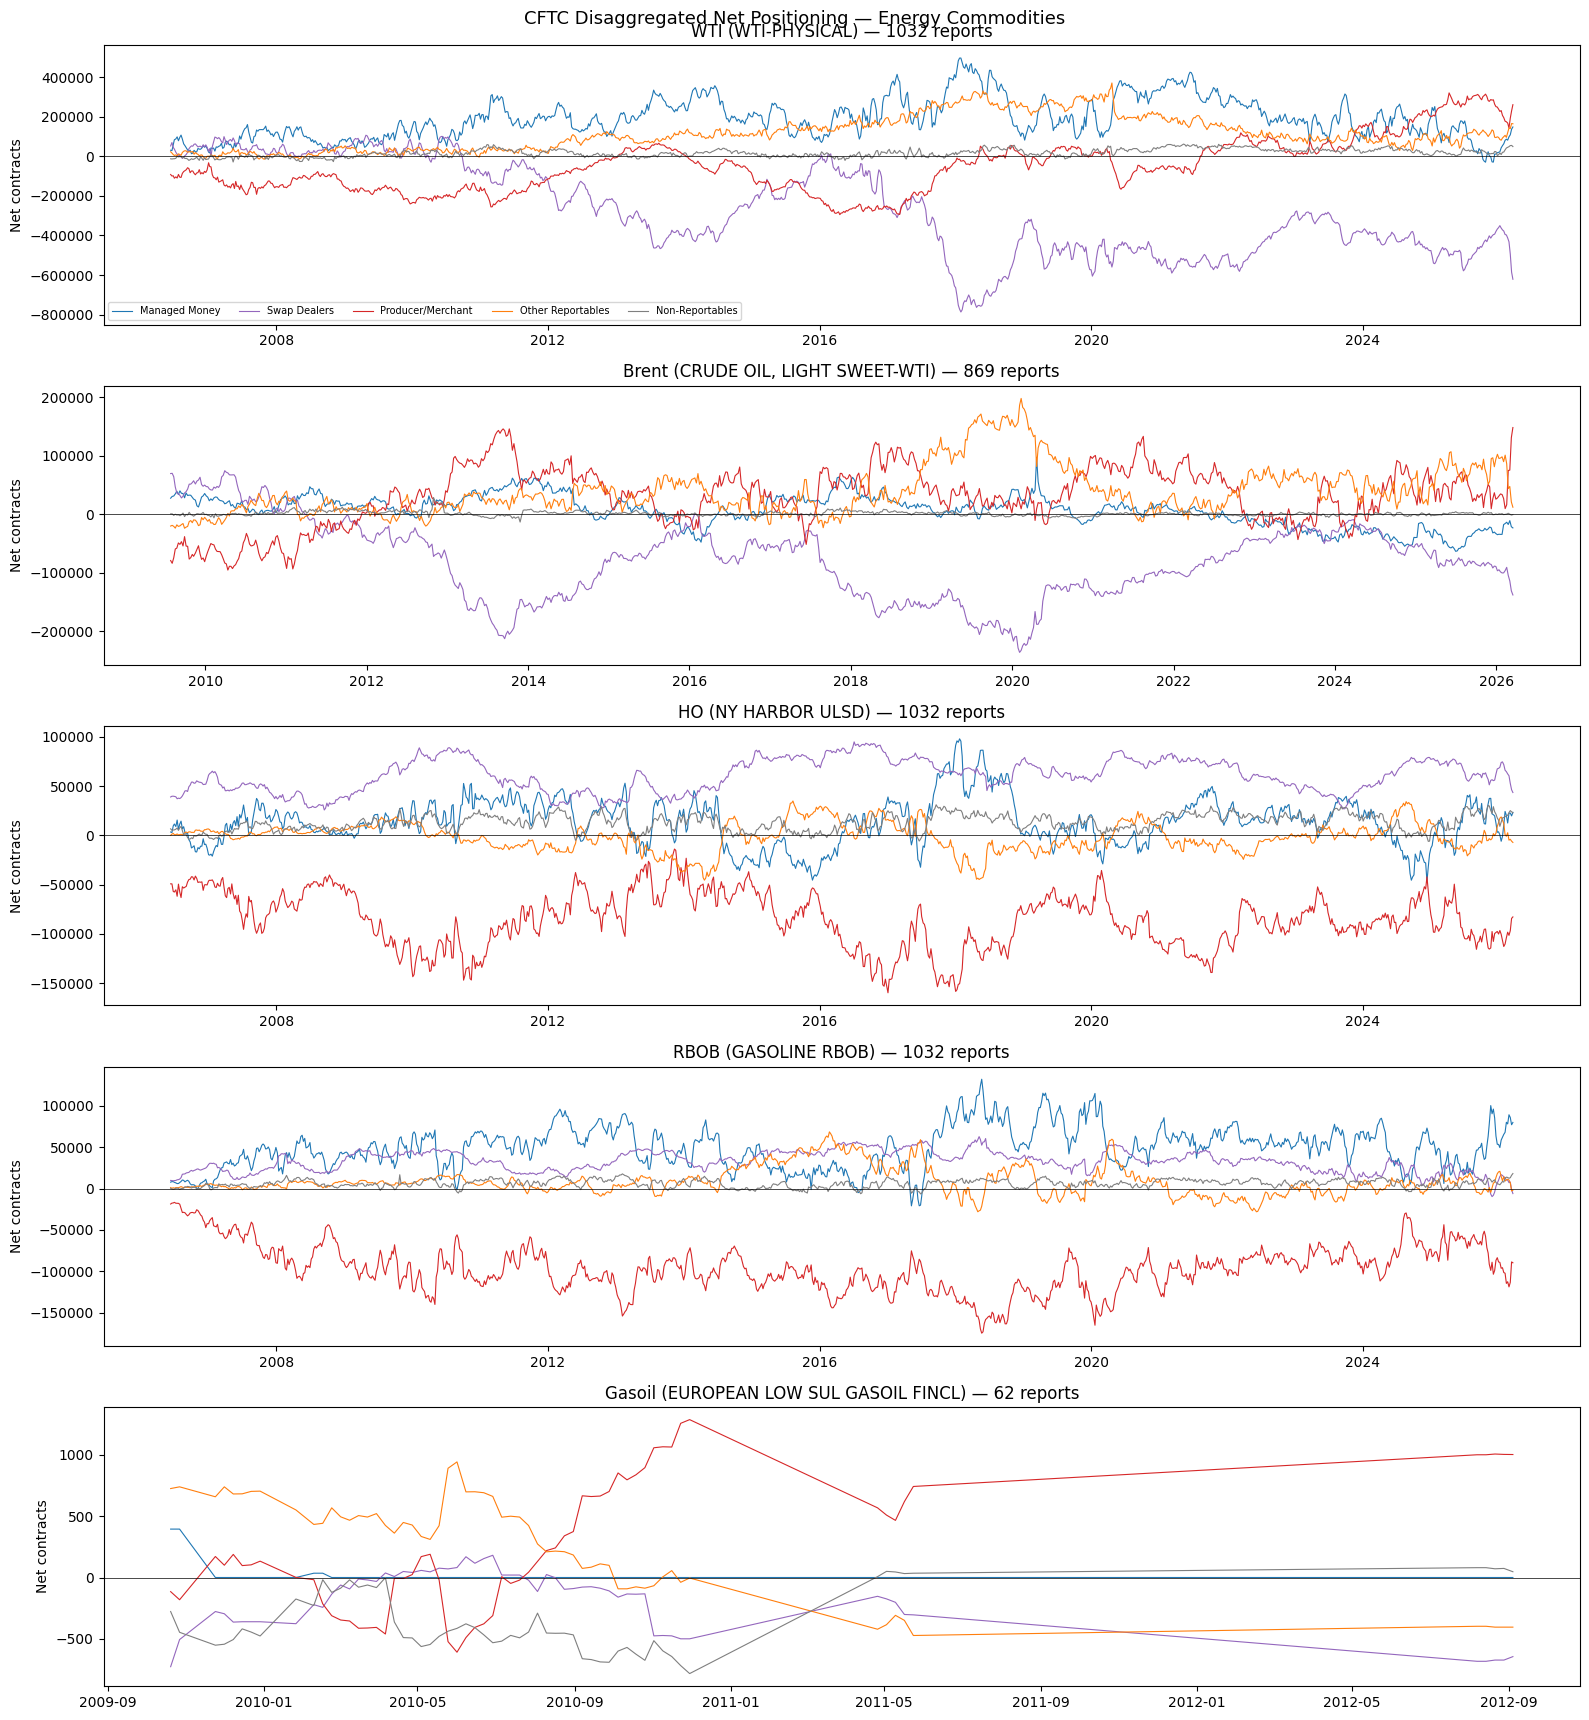

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(len(ENERGY_TICKERS), 1,
                         figsize=(16, 3.5 * len(ENERGY_TICKERS)), sharex=False)

for ax, (commodity, market_name) in zip(axes, ENERGY_TICKERS.items()):
    df = load_cftc_commodity(raw, market_name)
    if len(df) == 0:
        ax.set_title(f'{commodity} — NOT FOUND')
        continue
    
    for cat, color in [('Managed Money', 'tab:blue'),
                        ('Swap Dealers', 'tab:purple'),
                        ('Producer/Merchant', 'tab:red'),
                        ('Other Reportables', 'tab:orange'),
                        ('Non-Reportables', 'tab:grey')]:
        ax.plot(df['as_of_date'], df[f'{cat}_net'], label=cat,
                color=color, lw=0.8)
    
    ax.axhline(0, color='black', lw=0.5)
    ax.set_title(f'{commodity} ({market_name}) — {len(df)} reports')
    ax.set_ylabel('Net contracts')
    if ax == axes[0]:
        ax.legend(fontsize=7, loc='lower left', ncol=5)

plt.suptitle('CFTC Disaggregated Net Positioning — Energy Commodities', fontsize=13)
plt.tight_layout()
plt.show()

## 4. Other crude oil contracts in the data

For reference: all crude-related contracts available,
in case you need financials, spreads, or options data.

In [5]:
for commodity_name in ['CRUDE OIL', 'HEATING OIL-DIESEL-GASOIL', 'GASOLINE']:
    sub = raw[raw['commodity_name'] == commodity_name]
    contracts = sub.groupby('contract_market_name').agg(
        code=('cftc_contract_market_code', 'first'),
        n_reports=('report_date_as_yyyy_mm_dd', 'count'),
    ).sort_values('n_reports', ascending=False)
    
    print(f'\n=== {commodity_name} ({len(contracts)} contracts) ===')
    print(contracts.head(10).to_string())


=== CRUDE OIL (36 contracts) ===
                                code  n_reports
contract_market_name                           
WTI-PHYSICAL                  067651       1032
WTI FINANCIAL CRUDE OIL       06765A        971
CRUDE OIL AVG PRICE OPTIONS   06765C        928
CRUDE OIL, LIGHT SWEET-WTI    067411        869
BRENT LAST DAY                06765T        779
CRUDE OIL CAL SPREAD OPTIONS  067657        741
EUR STYLE CRUDE OIL OPTIONS   06765B        520
CRUDE DIFF-TMX WCS 1A INDEX   06742G        422
WTI-BRENT SPREAD OPTION       06765Z        406
WTI  HOUSTON ARGUS/WTI TR MO  0676A5        398

=== HEATING OIL-DIESEL-GASOIL (14 contracts) ===
                                 code  n_reports
contract_market_name                            
NY HARBOR ULSD                 022651       1032
UP DOWN GC ULSD VS HO SPR      022A13        554
SING GASOIL                    02265J        266
SING GASOIL ICE GASOIL         02265T        237
HEATING OIL AVG PRICE OPTIONS  022653        1

## 5. Quick reference

```python
# Filter by contract name (preferred — readable)
wti   = raw[raw['contract_market_name'] == 'WTI-PHYSICAL']
brent = raw[raw['contract_market_name'] == 'CRUDE OIL, LIGHT SWEET-WTI']
ho    = raw[raw['contract_market_name'] == 'NY HARBOR ULSD']
rbob  = raw[raw['contract_market_name'] == 'GASOLINE RBOB']
gasoil = raw[raw['contract_market_name'] == 'EUROPEAN LOW SUL GASOIL FINCL']

# Or by CFTC code
wti   = raw[raw['cftc_contract_market_code'] == '067651']
brent = raw[raw['cftc_contract_market_code'] == '067411']
ho    = raw[raw['cftc_contract_market_code'] == '022651']
rbob  = raw[raw['cftc_contract_market_code'] == '111659']
gasoil = raw[raw['cftc_contract_market_code'] == '02265V']
```